In [1]:
import os
import sys
import random
import optuna
import numpy as np
import pandas as pd
from dotenv import load_dotenv

sys.path.append("..")
from feature_engineering import time_based_train_test_split, get_return, round_to_step, get_mask, add_week_column, objective, get_best_features, get_feature_bins_map
from etl_pipeline_local import get_x_table

sys.path.append("../..")
from strategies.strategies_utils import analyze_strategies, get_best_strategies

from utils import trial_key, run_one_study
pd.set_option('display.max_columns', None)
optuna.logging.set_verbosity(optuna.logging.WARN)

load_dotenv()

True

# 1. Load Data

In [10]:
# Bet setup
target_col = "tie"
odds_col: str = "chance1x2_quote_currentx"

# Load data
df_loaded = get_x_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]

feature_bins_map = {
'chance1x2_xg_home': 0.1, 
'chance1x2_xg_away': 0.1, 
'chance1x2_xg_total': 0.1,
 }

df = df.dropna(subset=feature_bins_map.keys())
# Train/test split
df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)

## 2. Define Parameters

In [ ]:
# Define features and relative step

objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 50, # 50
    "min_obs": 100, 
    "lambda": 1, # 0.5, 1, 2
    "tpe_sampler": 
    {
        "n_startup_trials": 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
        "n_ei_candidates": 128 # 24 default, problemi difficili: 64 o 128
    }
}

# Create the binned dataframe
df_train_binned = df_train.dropna(subset=feature_bins_map.keys()).copy()


for feat, step in feature_bins_map.items():
    df_train_binned[feat] = [round_to_step(x, step) for x in df_train_binned[feat]]

    if isinstance(step, int):
        df_train_binned[feat] = df_train_binned[feat].astype("Int64")

print("SEARCH SPACE\n")
for feat in feature_bins_map.keys():
    space = df_train_binned[feat].sort_values(ascending=True).unique()
    print(f"Feature: {feat}")
    print(f"Search space: {space}")
    print("\n")

SEARCH SPACE

Feature: chance1x2_xg_home
Search space: [0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3
 2.4 2.6]


Feature: chance1x2_xg_away
Search space: [0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2
 2.3 2.4]


Feature: chance1x2_xg_total
Search space: [1.4 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2
 3.3 3.4 3.5 3.6 3.7 3.8]




## 3. Optimize

In [23]:
optuna.logging.set_verbosity(optuna.logging.WARN)

# Generate random seeds
seeds = [random.randint(0, 2**32 - 1) for _ in range(objective_hyperparameters["n_studies"])]
studies = [
    run_one_study(
        seed=s, 
        objective_hyperparameters=objective_hyperparameters, 
        objective=objective,
        feature_bins_map=feature_bins_map, 
        df_binned=df_train_binned
        ) 
        for s in seeds]

all_trials = []
for study in studies:
    all_trials.extend(
        [t for t in study.trials if t.value is not None and t.state.name == "COMPLETE"]
    )

top_trials = sorted(all_trials, key=lambda t: -t.value)
best_trials = top_trials[:10]
print(best_trials)

/home/maicolnicolini/code/bet-master-analytics/src/models/tie/../feature_engineering.py:321: UserWarning: The distribution is specified by [0.6000000000000001, 2.5] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.4].
  feat_min = trial.suggest_float(
/home/maicolnicolini/code/bet-master-analytics/src/models/tie/../feature_engineering.py:327: UserWarning: The distribution is specified by [0.6000000000000001, 2.6] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.5].
  feat_max = trial.suggest_float(
/home/maicolnicolini/code/bet-master-analytics/src/models/tie/../feature_engineering.py:321: UserWarning: The distribution is specified by [0.5, 2.3000000000000003] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.5, 2.3].
  feat_min = trial.suggest_float(
/home/maicolnicolini/code/bet-master-analytics/src/models/tie/../feature_engineering.py:327: U

[FrozenTrial(number=488, state=<TrialState.COMPLETE: 1>, values=[0.13818218347963773], datetime_start=datetime.datetime(2026, 9, 2, 18, 10, 58, 660522), datetime_complete=datetime.datetime(2026, 9, 2, 18, 10, 58, 690478), params={'chance1x2_xg_home_use_min': False, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 0.7000000000000001, 'chance1x2_xg_home_max': 1.8000000000000003, 'chance1x2_xg_away_use_min': False, 'chance1x2_xg_away_use_max': True, 'use_chance1x2_xg_away': True, 'chance1x2_xg_away_min': 0.7, 'chance1x2_xg_away_max': 1.1, 'chance1x2_xg_total_use_min': True, 'chance1x2_xg_total_use_max': False, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 2.4000000000000004, 'chance1x2_xg_total_max': 2.9000000000000004}, user_attrs={'params_dict': {'chance1x2_xg_home_use_min': False, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 0.7000000000000001, 'chance1x2_xg_home_max': 1.8000000000000003

## 4. Evaluate

In [24]:
# Create the test binned dataframe
return_threshold = -10.
df_test_binned = df_test.copy()

for feat, step in feature_bins_map.items():
    df_test_binned[feat] = [round_to_step(x, step) for x in df_test_binned[feat]]

    if isinstance(step, int):
        df_test_binned[feat] = df_test_binned[feat].astype("Int64")

# Get the resulting dataframes
for i, trial in enumerate(best_trials):
    params_dict = best_trials[i].user_attrs["params_dict"]

    train_mask = get_mask(df_train_binned, params_dict)
    test_mask = get_mask(df_test_binned, params_dict)

    df_train_filtered = df_train_binned[train_mask]
    df_test_filtered = df_test_binned[test_mask]

    df = pd.concat([df_train_filtered, df_test_filtered], axis=0)
    min_return = df.groupby('week')['return'].sum().min()
    max_return = df.groupby('week')['return'].sum().max()

    if min_return >= return_threshold:
        print(f"Trial no. {i}")
        print(f"Min return {min_return}")
        print(f"Max return {max_return}")
        print(f"Score {trial.value}")
        print("\n")

Trial no. 0
Min return -8.850000000000001
Max return 8.6
Score 0.13818218347963773


Trial no. 1
Min return -8.850000000000001
Max return 8.6
Score 0.13818218347963773


Trial no. 2
Min return -8.850000000000001
Max return 8.6
Score 0.13818218347963773




Mean Train ROI: 0.08078947368421056
Train Accuracy: 0.3 (64/228)
Mean Test ROI: -0.22876712328767126
Test Accuracy: 0.2 (14/73)


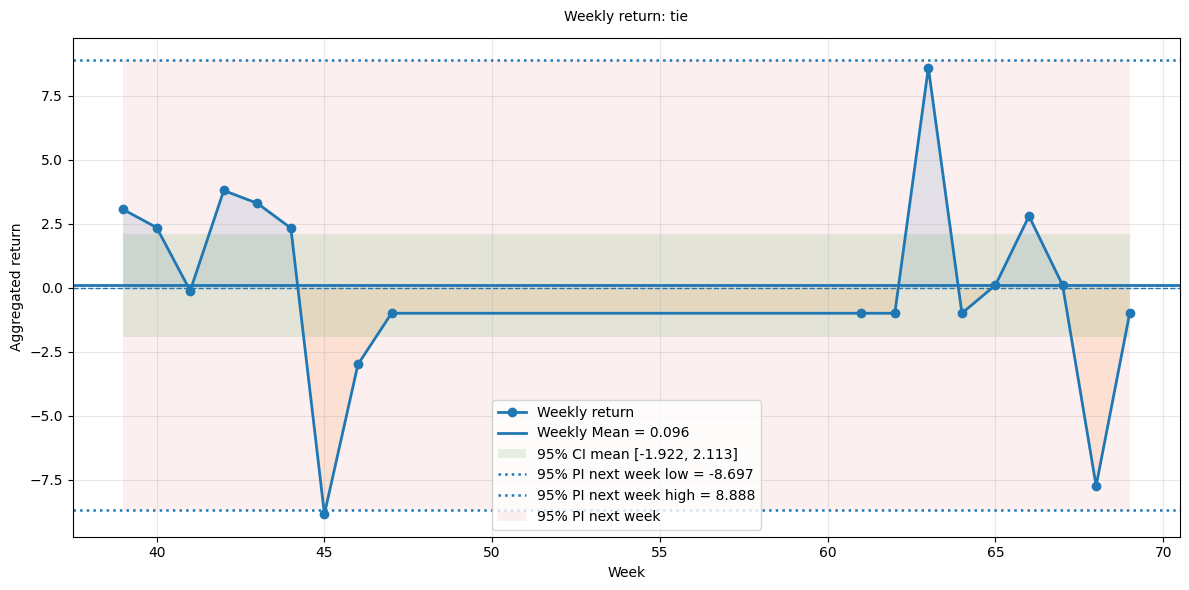

In [25]:
best_score_idx = 0

params_dict = best_trials[best_score_idx].user_attrs["params_dict"]

train_mask = get_mask(df_train_binned, params_dict)
test_mask = get_mask(df_test_binned, params_dict)

df_train_filtered = df_train_binned[train_mask]
df_test_filtered = df_test_binned[test_mask]


mean_roi = df_train_filtered["return"].mean()
right = df_train_filtered[target_col].sum()  
total = df_train_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Train ROI: {mean_roi}")
print(f"Train Accuracy: {accuracy} ({right}/{total})")


mean_roi = df_test_filtered["return"].mean()
right = df_test_filtered[target_col].sum()  
total = df_test_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Test ROI: {mean_roi}")
print(f"Test Accuracy: {accuracy} ({right}/{total})")


df_tot_filtered = pd.concat([df_train_filtered, df_test_filtered], axis=0).reset_index(drop=True).rename(columns={target_col: "result", "time": "date"})
df_tot_filtered = df_tot_filtered.sort_values(by="date", ascending=False)
 
df_tot_filtered["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_tot_filtered, strategies=[target_col], print_pi=True)

In [21]:
# Get Stats
weeks = stats["n_weeks"]
total_weeks = max(df["week"])

print(f"No. of weeks covered: {weeks}/{total_weeks} ({np.round((weeks/total_weeks), 2)})")
weekly_stats = get_best_strategies(df_tot_filtered).iloc[0].to_dict()
weekly_stats["weeks_covered"] = np.round((weeks/total_weeks), 2)

get_best_strategies(df_tot_filtered)

No. of weeks covered: 16/69 (0.23)


,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
tie,0.43,4.42,3.76,9.90,256,0.21


## 5. Save best Trials

In [8]:
# Save best trials 
trial_to_save = best_trials[best_score_idx]

trial_to_save.set_user_attr("feature_bins_map", feature_bins_map)
trial_to_save.set_user_attr("weekly_stats", weekly_stats) 

study = optuna.create_study(
    study_name=f"{target_col}_aggregated_study",
    storage=os.getenv("OPTUNA_STORAGE"),
    direction="maximize",   
    load_if_exists=True,
)

existing = {trial_key(t) for t in study.trials if t.value is not None}

# esempio: best_frozen_trials = [study_seed_1.best_trial, study_seed_2.best_trial, ...]
new_best_trials = [
    t for t in [trial_to_save]
    if trial_key(t) not in existing
]

if new_best_trials:
    study.add_trials(new_best_trials)

print("Aggiunti:", len(new_best_trials))
print("Totale trial archiviati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

Aggiunti: 1
Totale trial archiviati: 1
Best assoluto: -2.2134251539151437 {'chance1x2_xg_home_use_min': False, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 1.5, 'chance1x2_xg_home_max': 2.2, 'chance1x2_xg_away_use_min': True, 'chance1x2_xg_away_use_max': False, 'use_chance1x2_xg_away': True, 'chance1x2_xg_away_min': 1.3, 'chance1x2_xg_away_max': 1.5, 'chance1x2_xg_total_use_min': True, 'chance1x2_xg_total_use_max': False, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 3.1000000000000005, 'chance1x2_xg_total_max': 3.4000000000000004}


/tmp/ipykernel_67897/4034433927.py:26: UserWarning: The distribution is specified by [0.6000000000000001, 2.4] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.3000000000000003].
  print("Totale trial archiviati:", len(study.trials))
/tmp/ipykernel_67897/4034433927.py:26: UserWarning: The distribution is specified by [0.6000000000000001, 2.5] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.4].
  print("Totale trial archiviati:", len(study.trials))
/tmp/ipykernel_67897/4034433927.py:26: UserWarning: The distribution is specified by [1.4000000000000001, 3.6] and step=0.1, but the range is not divisible by `step`. It will be replaced with [1.4000000000000001, 3.5].
  print("Totale trial archiviati:", len(study.trials))
/tmp/ipykernel_67897/4034433927.py:26: UserWarning: The distribution is specified by [1.4000000000000001, 3.8000000000000003] and step=0.1, but the range is not di